<a href="https://colab.research.google.com/github/rdario-a11y/Sistema-de-registro-/blob/main/Desafio_AluraStore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1.Análisis de Facturación**

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [6]:
import os
print(os.listdir())

['.config', 'tienda_3.csv', 'tienda_1 .csv', 'AluraStoreLatam.ipynb', 'tienda_4.csv', 'tienda_2.csv', 'sample_data']


In [7]:
df = pd.read_csv('tienda_1 .csv')
df.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB


In [9]:
df.isnull().sum()

,0
Producto,0
Categoría del Producto,0
Precio,0
Costo de envío,0
Fecha de Compra,0
Vendedor,0
Lugar de Compra,0
Calificación,0
Método de pago,0
Cantidad de cuotas,0


In [10]:
df = df.drop_duplicates()
print("¡Duplicados eliminados!")

¡Duplicados eliminados!


In [11]:
df.describe()

,Precio,Costo de envío,Calificación,Cantidad de cuotas,lat,lon
count,2.359000e+03,2359.000000,2359.000000,2359.000000,2359.000000,2359.000000
mean,4.878679e+05,26018.609580,3.976685,2.943196,5.365283,-74.789417
std,6.146868e+05,32860.001783,1.415370,2.819897,2.287445,1.217827
min,7.600000e+03,0.000000,1.000000,1.000000,-4.215280,-77.281110
25%,5.575000e+04,3100.000000,3.000000,1.000000,4.609710,-75.563590
50%,2.353000e+05,12400.000000,5.000000,1.000000,4.609710,-74.199040
75%,6.781000e+05,36000.000000,5.000000,4.000000,6.251840,-74.081750
max,2.977000e+06,160800.000000,5.000000,24.000000,11.544440,-67.923900


In [12]:
df['Fecha de Compra'] = pd.to_datetime(df['Fecha de Compra'], dayfirst=True)

In [13]:
print(df['Fecha de Compra'].dtype)
df.head()

datetime64[ns]


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,2021-01-16,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,2022-05-18,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,2021-03-15,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,2022-05-03,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,2020-11-07,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [14]:
df['Total_Venta'] = df['Precio'] + df['Costo de envío']

In [15]:
df[['Producto', 'Precio', 'Costo de envío', 'Total_Venta']].head()

,Producto,Precio,Costo de envío,Total_Venta
0,Asistente virtual,164300.0,6900.0,171200.0
1,Mesa de comedor,192300.0,8400.0,200700.0
2,Juego de mesa,209600.0,15900.0,225500.0
3,Microondas,757500.0,41000.0,798500.0
4,Silla de oficina,335200.0,20200.0,355400.0


In [16]:
ventas_por_categoria = df.groupby('Categoría del Producto')['Total_Venta'].sum().sort_values(ascending=False)


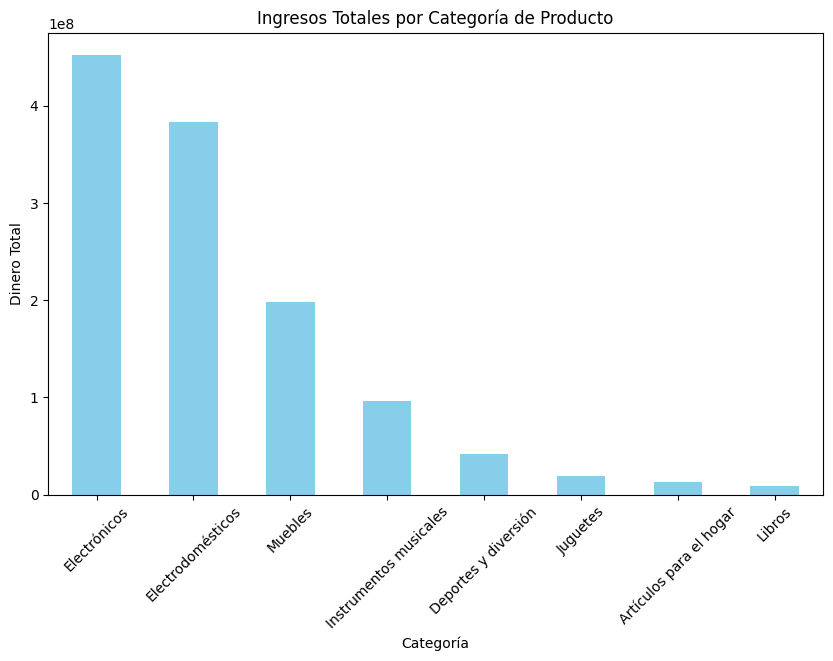

In [17]:
plt.figure(figsize=(10,6))
ventas_por_categoria.plot(kind='bar', color='skyblue')
plt.title('Ingresos Totales por Categoría de Producto')
plt.xlabel('Categoría')
plt.ylabel('Dinero Total')
plt.xticks(rotation=45)
plt.show()

In [18]:
df['Mes_Año'] = df['Fecha de Compra'].dt.to_period('M').astype(str)

In [19]:
ventas_mensuales = df.groupby('Mes_Año')['Total_Venta'].sum()

In [20]:
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

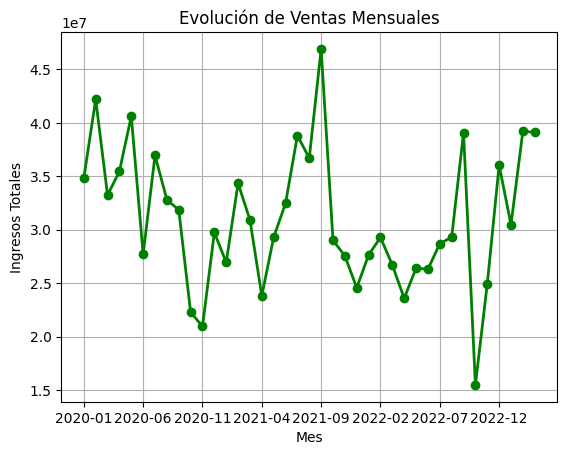

In [21]:
ventas_mensuales.plot(kind='line', marker='o', color='green', linewidth=2)
plt.title('Evolución de Ventas Mensuales')
plt.xlabel('Mes')
plt.ylabel('Ingresos Totales')
plt.grid(True)
plt.show()

In [22]:
ranking_vendedores = df.groupby('Vendedor')['Total_Venta'].sum().sort_values(ascending=False)

In [23]:
print("Top 5 Vendedores:")
print(ranking_vendedores.head(5))

Top 5 Vendedores:
Vendedor
Maria Alfonso      106844300.0
Rafael Acosta      101399800.0
Izabela de León     98764900.0
Felipe Santos       95048000.0
Juliana Costa       90258700.0
Name: Total_Venta, dtype: float64


/tmp/ipykernel_822/669485133.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ranking_vendedores.values, y=ranking_vendedores.index, palette='magma')


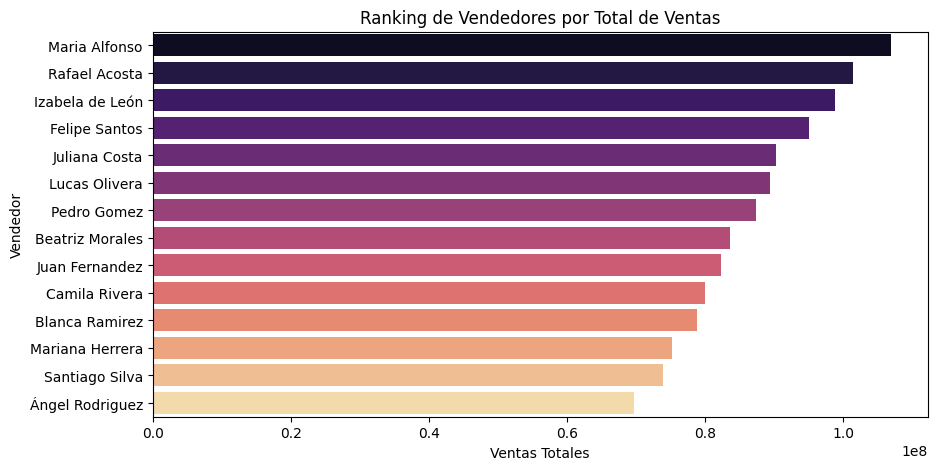

In [24]:
plt.figure(figsize=(10,5))
sns.barplot(x=ranking_vendedores.values, y=ranking_vendedores.index, palette='magma')
plt.title('Ranking de Vendedores por Total de Ventas')
plt.xlabel('Ventas Totales')
plt.ylabel('Vendedor')
plt.show()

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar todas las tiendas
url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

# 2. Unirlas en un solo DataFrame llamado 'df_final'
df_final = pd.concat([pd.read_csv(url), pd.read_csv(url2), pd.read_csv(url3), pd.read_csv(url4)], ignore_index=True)

# 3. Aplicar la limpieza
df_final['Fecha de Compra'] = pd.to_datetime(df_final['Fecha de Compra'], dayfirst=True)
df_final['Total_Venta'] = df_final['Precio'] + df_final['Costo de envío']
df_final = df_final.drop_duplicates()

print(f"super tabla con {len(df_final)} filas lista para analizar.")

super tabla con 9435 filas lista para analizar.


In [27]:
print(df_final.isnull().sum())

Producto                  0
Categoría del Producto    0
Precio                    0
Costo de envío            0
Fecha de Compra           0
Vendedor                  0
Lugar de Compra           0
Calificación              0
Método de pago            0
Cantidad de cuotas        0
lat                       0
lon                       0
Total_Venta               0
dtype: int64


/tmp/ipykernel_822/4261420924.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_por_lugar.index, y=ventas_por_lugar.values, palette='viridis')


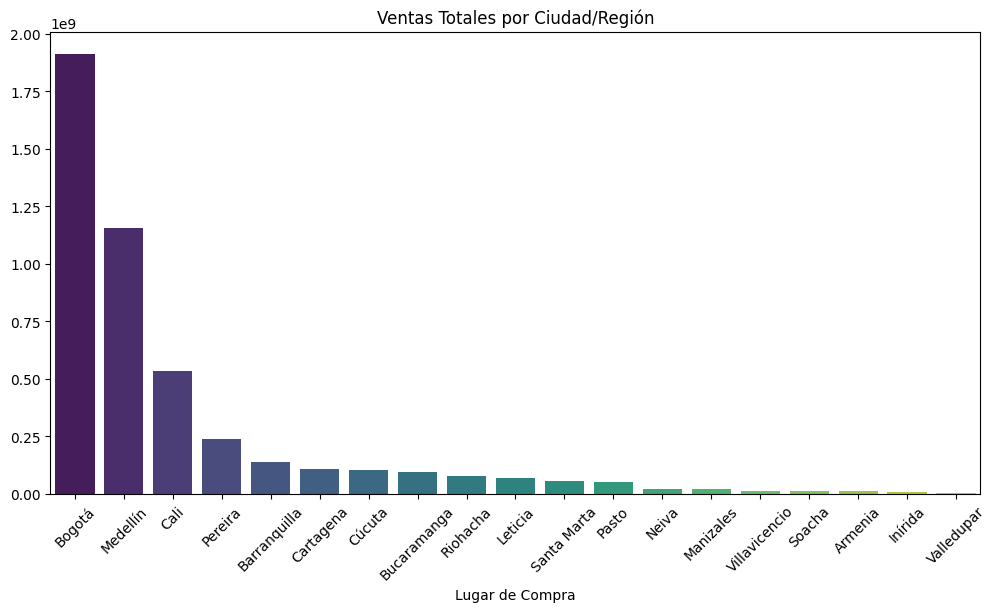

In [28]:
# Agrupamos por Lugar de Compra
ventas_por_lugar = df_final.groupby('Lugar de Compra')['Total_Venta'].sum().sort_values(ascending=False)

# Gráfica de Barras
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(x=ventas_por_lugar.index, y=ventas_por_lugar.values, palette='viridis')
plt.title('Ventas Totales por Ciudad/Región')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_822/174382578.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias_global.values, y=categorias_global.index, palette='Blues_r')


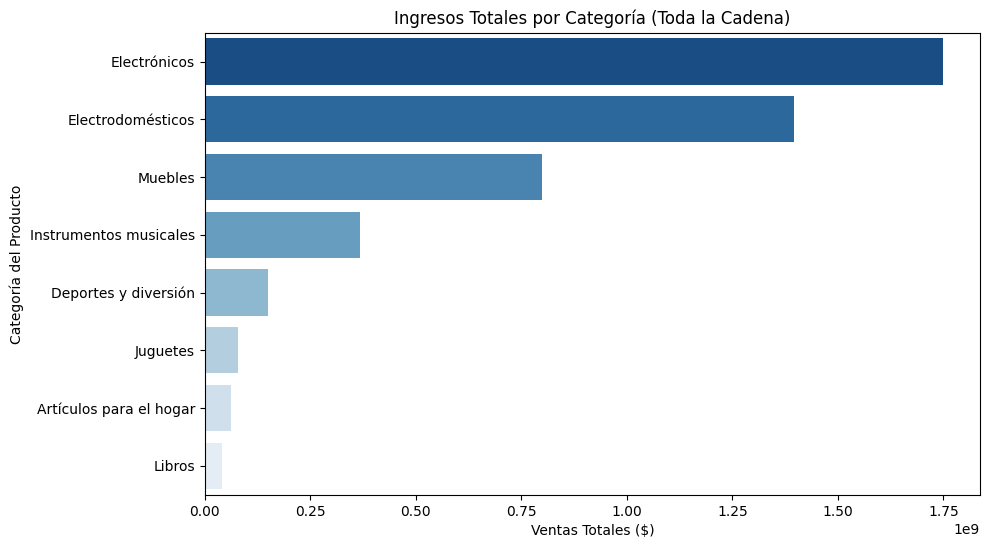

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupamos por categoría sobre el DataFrame final
categorias_global = df_final.groupby('Categoría del Producto')['Total_Venta'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=categorias_global.values, y=categorias_global.index, palette='Blues_r')
plt.title('Ingresos Totales por Categoría (Toda la Cadena)')
plt.xlabel('Ventas Totales ($)')
plt.show()

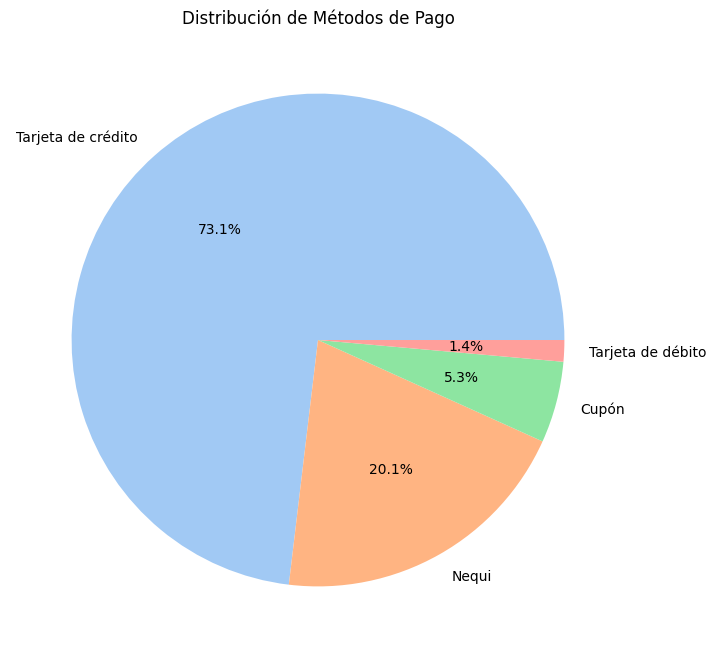

In [30]:
metodos_pago = df_final['Método de pago'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(metodos_pago, labels=metodos_pago.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Distribución de Métodos de Pago')
plt.show()

In [31]:
# Sacamos el promedio de calificación y el total de ventas por vendedor
vendedores_stats = df_final.groupby('Vendedor').agg({
    'Total_Venta': 'sum',
    'Calificación': 'mean'
}).sort_values(by='Total_Venta', ascending=False).head(10)

print("Top 10 Vendedores por Desempeño Global:")
print(vendedores_stats)

Top 10 Vendedores por Desempeño Global:
                 Total_Venta  Calificación
Vendedor                                  
Felipe Santos    372652300.0      4.075606
Izabela de León  368964800.0      3.858871
Maria Alfonso    368282900.0      3.957290
Juliana Costa    356385400.0      3.918759
Pedro Gomez      330020800.0      4.041221
Rafael Acosta    326829100.0      4.064000
Juan Fernandez   324965300.0      4.033141
Lucas Olivera    321683700.0      3.962908
Camila Rivera    319351500.0      4.032984
Beatriz Morales  318885100.0      4.047692


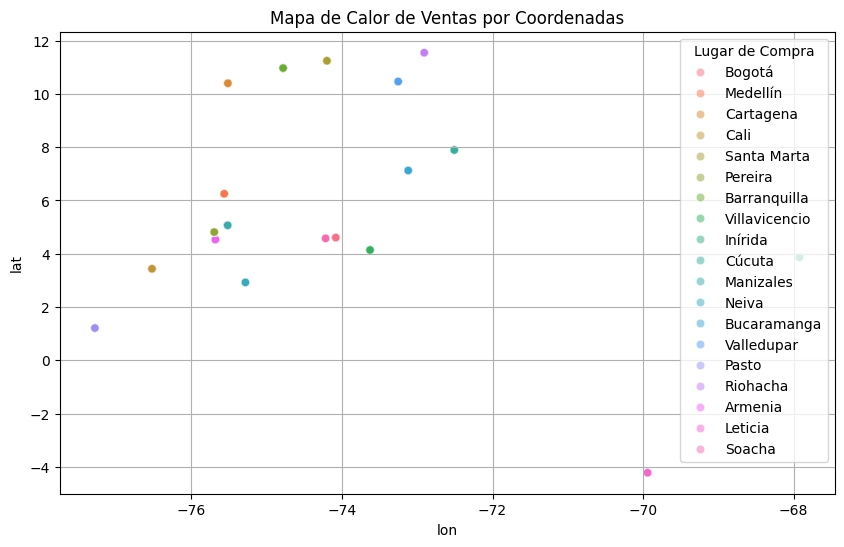

In [32]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_final, x='lon', y='lat', hue='Lugar de Compra', alpha=0.5)
plt.title('Mapa de Calor de Ventas por Coordenadas')
plt.grid(True)
plt.show()

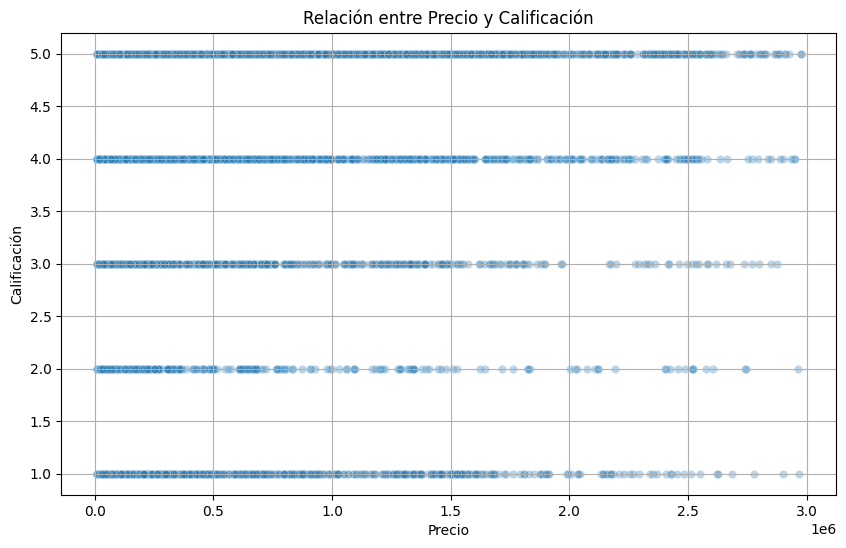

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Usamos un gráfico de dispersión (scatter plot)
sns.scatterplot(data=df_final, x='Precio', y='Calificación', alpha=0.3)
plt.title('Relación entre Precio y Calificación')
plt.grid(True)
plt.show()

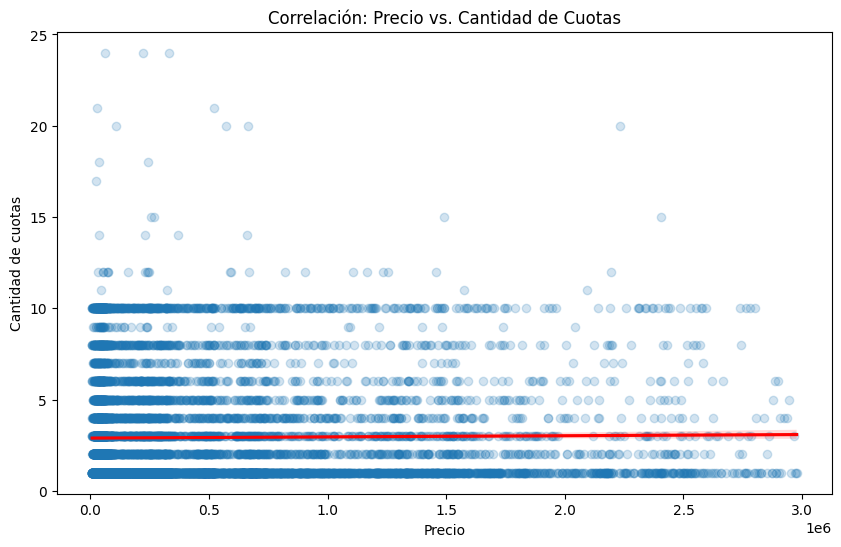

In [34]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_final, x='Precio', y='Cantidad de cuotas', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Correlación: Precio vs. Cantidad de Cuotas')
plt.show()

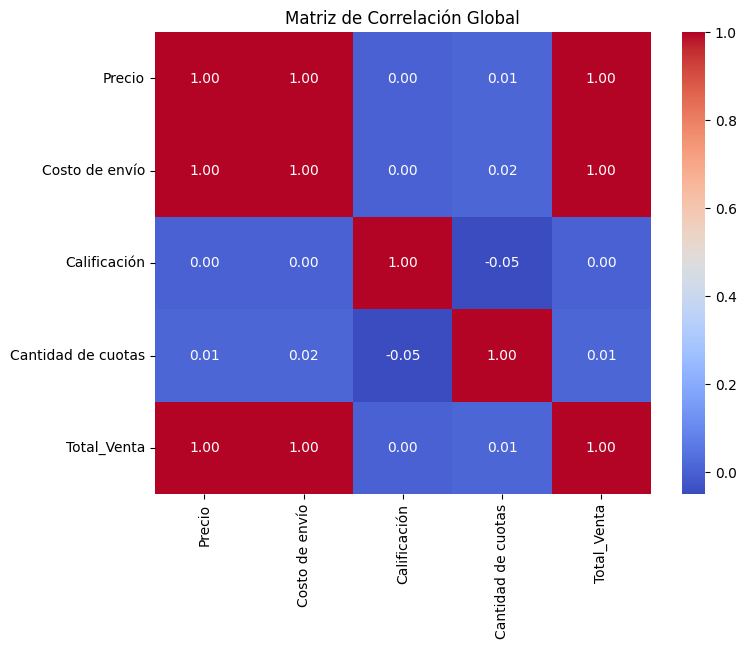

In [35]:
# Seleccionamos solo las columnas numéricas
corr = df_final[['Precio', 'Costo de envío', 'Calificación', 'Cantidad de cuotas', 'Total_Venta']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación Global')
plt.show()